# Customer Churn Prediction 



## Problem Statement
Predict whether a customer will churn based on behavioral and service features.

## Project Pipeline
1. Data Loading
2. Data Understanding
3. Exploratory Data Analysis
4. Preprocessing
5. Model Building
6. Evaluation
7. Comparison
8. Business Insights

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
RANDOM_STATE = 42


In [2]:
# Load dataset
df = pd.read_csv("data/customer_churn.csv")

print("Shape:", df.shape)
df.head()


Shape: (3150, 14)


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

# Data Exploration

In [4]:
df.duplicated().sum()

np.int64(300)

In [5]:
df.drop_duplicates(inplace=True)
df.shape

(2850, 14)

In [6]:
df["Churn"].value_counts()

Churn
0    2404
1     446
Name: count, dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.843509
1    0.156491
Name: proportion, dtype: float64

# Data Preprocessing

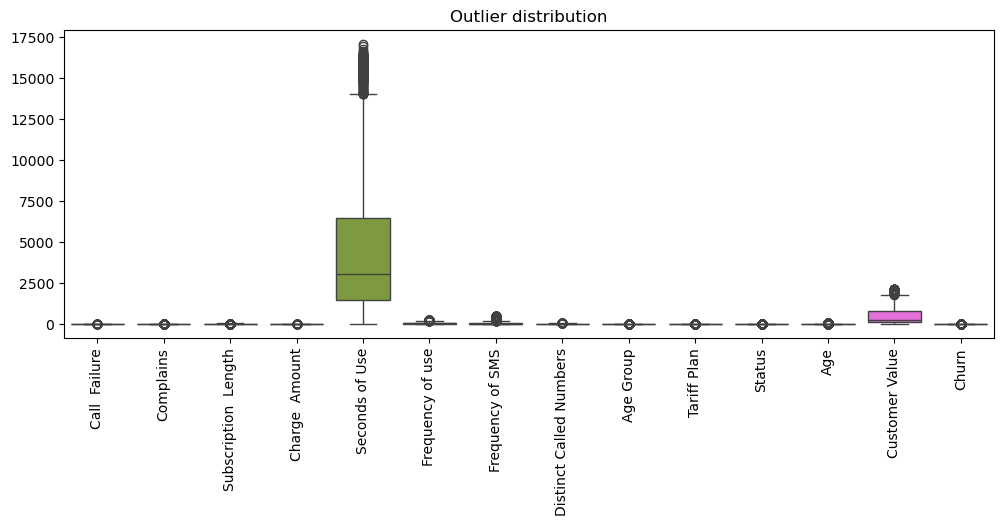

In [8]:
# Finding Outlier 
plt.figure(figsize=(12,4))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier distribution")
plt.show()

### Insight 
- Seconds of use represent outlier the most

In [9]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Call Failure,2850.0,7.802456,7.326172,0.0,1.0000,6.00,12.00,36.00
Complains,2850.0,0.080702,0.272424,0.0,0.0000,0.00,0.00,1.00
Subscription Length,2850.0,32.452982,8.723075,3.0,29.0000,35.00,38.00,47.00
Charge Amount,2850.0,0.974737,1.550618,0.0,0.0000,0.00,2.00,10.00
Seconds of Use,2850.0,4534.243158,4199.712303,0.0,1458.7500,3041.00,6500.00,17090.00
Frequency of use,2850.0,70.484912,57.401512,0.0,28.0000,54.50,96.00,255.00
Frequency of SMS,2850.0,73.789825,112.062397,0.0,7.0000,22.00,88.00,522.00
Distinct Called Numbers,2850.0,23.870526,17.193929,0.0,11.0000,21.00,34.00,97.00
Age Group,2850.0,2.835088,0.893503,1.0,2.0000,3.00,3.00,5.00
Tariff Plan,2850.0,1.080351,0.271883,1.0,1.0000,1.00,1.00,2.00


In [10]:
df.groupby("Churn").mean()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value
Churn,,,,,,,,,,,,,
0,7.792013,0.016639,32.595674,1.109401,5069.588186,77.866473,84.353577,25.872296,2.837354,1.092762,1.149334,31.121048,538.590759
1,7.858744,0.426009,31.683857,0.248879,1648.661435,30.697309,16.849776,13.080717,2.822870,1.013453,1.728700,30.840807,132.175695


In [11]:
#Corelation anaylsis
df.corr()["Churn"].sort_values(ascending=False)

Churn                      1.000000
Complains                  0.546055
Status                     0.492867
Call  Failure              0.003310
Age Group                 -0.005891
Age                       -0.011491
Subscription  Length      -0.037984
Tariff Plan               -0.106000
Charge  Amount            -0.201662
Frequency of SMS          -0.218894
Distinct Called Numbers   -0.270343
Customer Value            -0.287078
Seconds of Use            -0.295999
Frequency of use          -0.298608
Name: Churn, dtype: float64

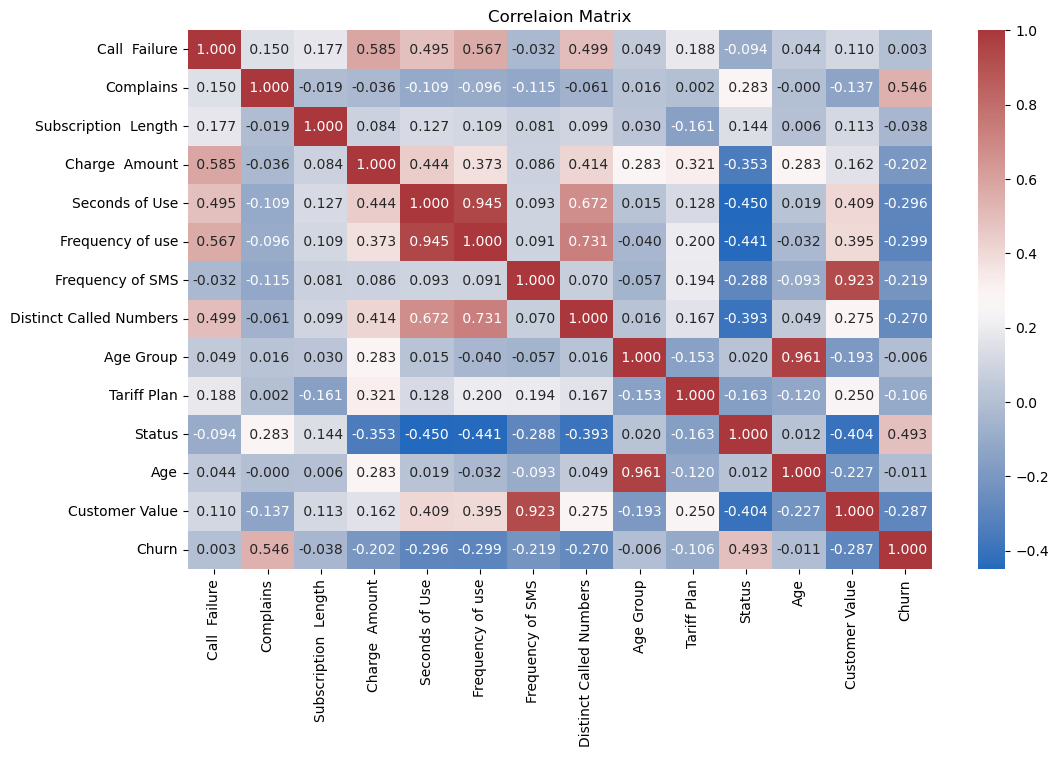

In [31]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(),annot=True, cmap="vlag", fmt=" .3f")
plt.title("Correlaion Matrix")
plt.show()

## Exploratory Data Analysis Insights

Key Observations:
- Dataset is imbalanced (~84% non-churn, 16% churn)
- Complaints strongly correlate with churn
- Usage metrics negatively correlate with churn
- Customers with low engagement are more likely to churn

Business Meaning:
Low usage + complaints = high churn risk segment

## Train-Test Split

We split data into training and testing sets to evaluate model generalization.
Stratification is used because the dataset is imbalanced.

In [13]:
from sklearn.model_selection import train_test_split
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)


# Model Training

## Logistic Regression Model

We start with Logistic Regression as a baseline model because it is simple and interpretable.

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight= "balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.83      0.89       481
           1       0.48      0.89      0.63        89

    accuracy                           0.84       570
   macro avg       0.73      0.86      0.76       570
weighted avg       0.90      0.84      0.85       570



In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver = "lbfgs"
)

model.fit(X_train_scaled, y_train)

y_pred= model.predict(X_test_scaled)


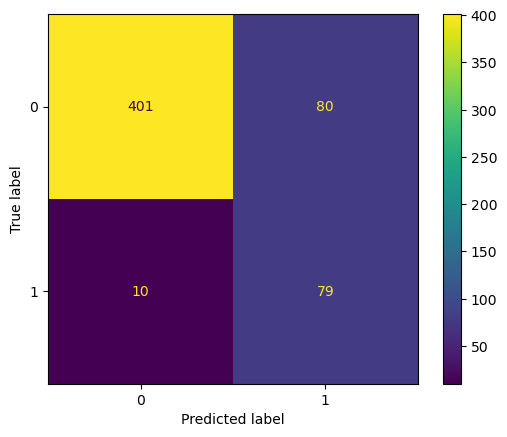

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix =cm)
disp.plot()

- True Negatives are very high → model predicts non-churn well.
- False Negatives are important → these are customers we fail to save.

ROC-AUC Score: 0.9270130112826741


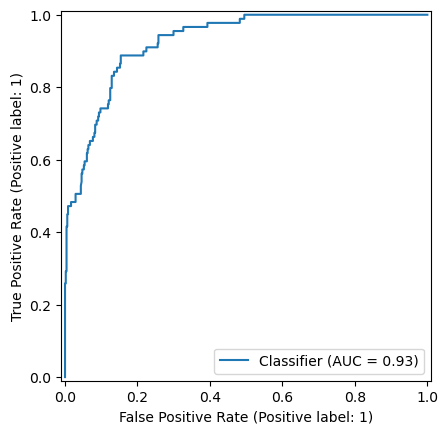

In [18]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_prob = model.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

RocCurveDisplay.from_predictions(y_test, y_prob)

In [19]:
from sklearn.metrics import classification_report
print ( classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.83      0.90       481
           1       0.50      0.89      0.64        89

    accuracy                           0.84       570
   macro avg       0.74      0.86      0.77       570
weighted avg       0.90      0.84      0.86       570



Default classification threshold is 0.5.
Lowering threshold increases recall for churn class, which is useful when detecting churners is more important than avoiding false positives.

In [20]:
y_pred_custom = (y_prob >=0.3).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.98      0.74      0.85       481
           1       0.40      0.93      0.56        89

    accuracy                           0.77       570
   macro avg       0.69      0.84      0.70       570
weighted avg       0.89      0.77      0.80       570



# Random Forest Model

Random Forest is used to capture nonlinear relationships and interactions between features.

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       481
           1       0.94      0.82      0.87        89

    accuracy                           0.96       570
   macro avg       0.95      0.90      0.93       570
weighted avg       0.96      0.96      0.96       570



In [22]:
from sklearn.metrics import roc_auc_score

rf_prob = rf.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest AUC:", rf_auc)

Random Forest AUC: 0.9850732322642435


## Cross Validation

Cross-validation confirms model stability across different data splits.

In [23]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")

print("CV AUC Scores:", cv_scores)
print("Mean CV AUC:", cv_scores.mean())

CV AUC Scores: [0.98174449 0.98503819 0.98300591 0.98423229 0.98100694]
Mean CV AUC: 0.983005565580706


## Feature Importance

In [24]:
pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

Complains                  0.195088
Subscription  Length       0.118076
Seconds of Use             0.117680
Status                     0.111129
Frequency of use           0.106346
Customer Value             0.084158
Distinct Called Numbers    0.076439
Call  Failure              0.065785
Frequency of SMS           0.053922
Age Group                  0.027998
Age                        0.027349
Charge  Amount             0.014409
Tariff Plan                0.001620
dtype: float64

## Feature Importance Analysis

We analyze which features influence churn the most to extract business insights.

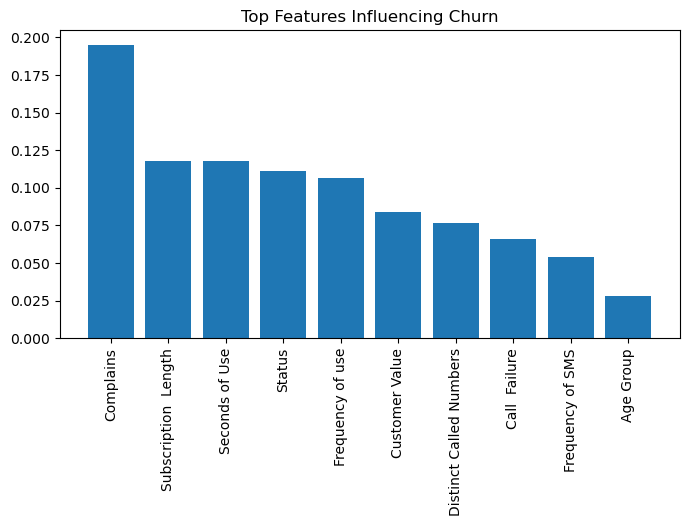

In [25]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,4))
plt.title("Top Features Influencing Churn")
plt.bar(range(10), importances[indices][:10])
plt.xticks(range(10), X.columns[indices][:10], rotation=90)
plt.show()

## Hyperparameter Tuning

In [26]:
from sklearn.model_selection import GridSearchCV, cross_val_score

params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(rf, params, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

tuned_rf = grid.best_estimator_
tuned_prob = tuned_rf.predict_proba(X_test)[:, 1]
tuned_auc = roc_auc_score(y_test, tuned_prob)
scores = cross_val_score(tuned_rf, X, y, cv=5, scoring="roc_auc")

print("Best Params:", grid.best_params_)
print("Tuned Random Forest AUC:", tuned_auc)


Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest AUC: 0.9849213950337546


## Model Comparison

In [27]:
# Model Selection
# We compared multiple algorithms and selected the best-performing model using ROC-AUC.

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Tuned Random Forest"],
    "Test AUC": [auc, rf_auc, tuned_auc],
})
comparison


,Model,Test AUC
0,Logistic Regression,0.927013
1,Random Forest,0.985073
2,Tuned Random Forest,0.984921


## Final Model Validation
The selected model was validated using cross-validation to ensure robustness.

In [28]:
final_score = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "CrossVal AUC": [scores.mean()],
})
final_score


,Model,CrossVal AUC
0,Tuned Random Forest,0.98462


## Evaluation

In [29]:
print("Train Score:", tuned_rf.score(X_train, y_train))
print("Test Score:", tuned_rf.score(X_test, y_test))


Train Score: 0.9864035087719298
Test Score: 0.9543859649122807


## ROC Curve

ROC curve evaluates the trade-off between true positive rate and false positive rate across thresholds.

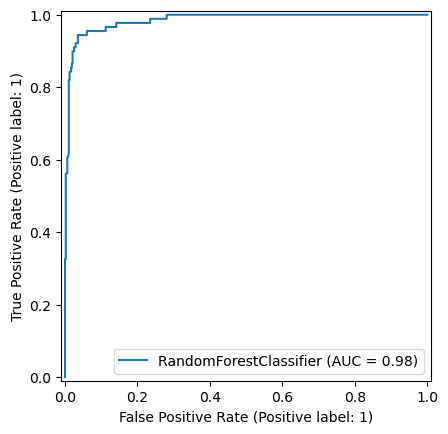

In [30]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(tuned_rf, X_test, y_test)


# Business Insights
- Customers with shorter tenure show higher churn probability.
- High complaint count strongly correlates with churn.
- High-value customers are at risk if complaints increase.
- Use threshold tuning to prioritize recall for churn prevention campaigns.
